# EDA — CMU Sleep & GPA Dataset
Exploratory Data Analysis sebelum training model prediksi IPK semester berdasarkan pola tidur mahasiswa.

**Dataset:** CMU + University of Washington Sleep Study  
**Target variable:** `term_gpa` (IPK semester berjalan)  
**Sumber:** Objective sleep data dari wearable tracker + catatan akademik


## 1. Imports Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')

df_raw = pd.read_csv('data/cmu-sleep.csv')
df_raw.columns = df_raw.columns.str.strip().str.lstrip('\ufeff')

print(f"Shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")

Shape: (634, 15)
Columns: ['subject_id', 'study', 'cohort', 'demo_race', 'demo_gender', 'demo_firstgen', 'bedtime_mssd', 'TotalSleepTime', 'midpoint_sleep', 'frac_nights_with_data', 'daytime_sleep', 'cum_gpa', 'term_gpa', 'term_units', 'Zterm_units_ZofZ']


## 2. Initial Inspection

In [2]:
df_raw.head(10)

,subject_id,study,cohort,demo_race,demo_gender,demo_firstgen,bedtime_mssd,TotalSleepTime,midpoint_sleep,frac_nights_with_data,daytime_sleep,cum_gpa,term_gpa,term_units,Zterm_units_ZofZ
0,185,5,lac1,1,1,0,0.116727,432.200000,458.660000,0.862069,24.160000,3.00,3.38,73,4.055294859
1,158,5,lac1,0,1,0,0.141681,391.931035,364.465517,1.000000,13.137931,3.66,2.60,64,2.482534122
2,209,5,lac1,1,1,0,1.529289,344.304348,560.891304,0.793103,14.956522,3.57,3.07,63,2.30778293
3,102,5,lac1,0,1,1,0.130148,392.620690,416.482759,1.000000,54.551724,3.61,3.56,61,1.958280544
4,174,5,lac1,1,1,0,0.130181,423.421053,368.763158,0.655172,10.526316,3.21,4.00,61,1.958280544
5,184,5,lac1,1,1,0,0.209483,397.400000,353.580000,0.862069,22.360000,3.20,3.36,60,1.783529351
6,255,5,lac1,1,1,0,0.675489,348.592593,434.703704,0.931034,20.518519,3.40,3.19,60,1.783529351
7,265,5,lac1,1,1,0,0.129622,422.111111,414.833333,0.931034,17.037037,3.86,3.28,60,1.783529351
8,343,5,lac1,1,0,0,1.476979,454.321429,423.821429,0.965517,52.678571,3.79,3.50,60,1.783529351
9,137,5,lac1,1,1,0,0.085000,308.965517,334.793103,1.000000,85.482759,3.53,2.55,59,1.608778158


In [3]:
df_raw.dtypes

subject_id                 int64
study                      int64
cohort                       str
demo_race                    str
demo_gender                  str
demo_firstgen                str
bedtime_mssd             float64
TotalSleepTime           float64
midpoint_sleep           float64
frac_nights_with_data    float64
daytime_sleep            float64
cum_gpa                  float64
term_gpa                 float64
term_units                   str
Zterm_units_ZofZ             str
dtype: object

In [4]:
# Cohort distribution — penting karena term_units kosong di cohort 'nh'
print("Cohort distribution:")
print(df_raw['cohort'].value_counts())
print()
print("Study distribution:")
print(df_raw['study'].value_counts())

Cohort distribution:
cohort
nh      147
uw1     140
uw2     139
lac1    131
lac2     77
Name: count, dtype: int64

Study distribution:
study
4    147
2    140
3    139
5    131
1     77
Name: count, dtype: int64


## 3. Missing Value Analysis

Identifikasi kolom yang punya missing value dan tentukan strategi: drop, impute median, atau drop kolom.


In [5]:
# Replace whitespace-only strings dengan NaN
df = df_raw.copy()
df = df.replace(r'^\s*$', np.nan, regex=True)

# Konversi kolom yang seharusnya numerik
numeric_cols = ['demo_race', 'demo_gender', 'demo_firstgen', 'term_units', 'Zterm_units_ZofZ']
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(missing_df)

                  Missing Count  Missing %
Zterm_units_ZofZ            147      23.19
term_units                  147      23.19
demo_firstgen                 4       0.63
demo_gender                   3       0.47
demo_race                     1       0.16


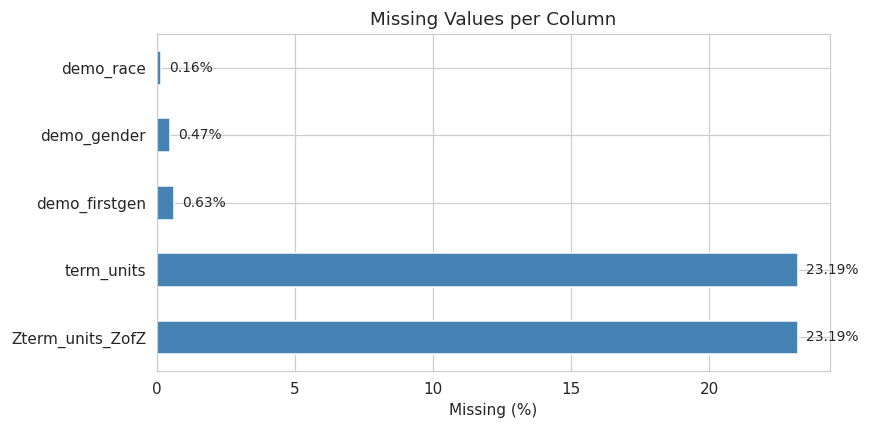


Catatan: term_units dan Zterm_units_ZofZ kosong 100% di cohort 'nh' (147 baris).
Ini bukan error random — cohort nh memang tidak punya data units.
Kedua kolom ini akan di-drop dari analisis.


In [6]:
# Visualisasi missing values
fig, ax = plt.subplots(figsize=(8, 4))
missing_df['Missing %'].plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Values per Column')
for i, v in enumerate(missing_df['Missing %']):
    ax.text(v + 0.3, i, f'{v}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print()
print("Catatan: term_units dan Zterm_units_ZofZ kosong 100% di cohort 'nh' (147 baris).")
print("Ini bukan error random — cohort nh memang tidak punya data units.")
print("Kedua kolom ini akan di-drop dari analisis.")

## 4. Data Cleaning

Strategi:
- Drop kolom `term_units` dan `Zterm_units_ZofZ` (missing 23.2%, struktural dari cohort nh)
- Drop kolom `subject_id` (identifier, tidak relevan)
- Missing `demo_gender`, `demo_firstgen`, `demo_race` (< 1%) → impute dengan **modus**
- Tidak ada missing di fitur utama tidur dan target `term_gpa`


In [7]:
df_clean = df.copy()

# Drop kolom tidak relevan / struktural missing
df_clean = df_clean.drop(columns=['subject_id', 'term_units', 'Zterm_units_ZofZ'])

# Impute demografi dengan modus (missing < 1%, tidak krusial)
for col in ['demo_gender', 'demo_firstgen', 'demo_race']:
    mode_val = df_clean[col].mode()[0]
    n_filled = df_clean[col].isnull().sum()
    df_clean[col] = df_clean[col].fillna(mode_val)
    print(f"{col}: {n_filled} nilai kosong diisi dengan modus = {mode_val}")

print(f"\nShape setelah cleaning: {df_clean.shape}")
print(f"Missing values tersisa: {df_clean.isnull().sum().sum()}")

demo_gender: 3 nilai kosong diisi dengan modus = 1.0
demo_firstgen: 4 nilai kosong diisi dengan modus = 0.0
demo_race: 1 nilai kosong diisi dengan modus = 1.0

Shape setelah cleaning: (634, 12)
Missing values tersisa: 0


## 5. Descriptive Statistics

In [8]:
features_of_interest = [
    'TotalSleepTime', 'midpoint_sleep', 'bedtime_mssd',
    'daytime_sleep', 'frac_nights_with_data', 'cum_gpa', 'term_gpa'
]

desc = df_clean[features_of_interest].describe().T
desc['cv'] = (desc['std'] / desc['mean'] * 100).round(2)  # coefficient of variation
desc.round(3)

,count,mean,std,min,25%,50%,75%,max,cv
TotalSleepTime,634.0,397.324,50.857,194.783,366.930,400.396,430.115,587.667,12.80
midpoint_sleep,634.0,398.679,72.711,247.071,345.183,388.246,437.655,724.667,18.24
bedtime_mssd,634.0,0.452,1.394,0.005,0.075,0.135,0.292,20.849,308.54
daytime_sleep,634.0,41.164,27.389,2.269,23.098,34.982,51.249,292.304,66.54
frac_nights_with_data,634.0,0.867,0.179,0.214,0.821,0.932,1.000,1.000,20.63
cum_gpa,634.0,3.466,0.438,1.210,3.232,3.558,3.790,4.000,12.63
term_gpa,634.0,3.450,0.500,0.350,3.233,3.556,3.810,4.000,14.51


In [9]:
# Konversi TotalSleepTime ke jam untuk readability
print("Rata-rata tidur per malam:", round(df_clean['TotalSleepTime'].mean() / 60, 2), "jam")
print("Median tidur per malam:  ", round(df_clean['TotalSleepTime'].median() / 60, 2), "jam")
print("Min tidur per malam:     ", round(df_clean['TotalSleepTime'].min() / 60, 2), "jam")
print("Max tidur per malam:     ", round(df_clean['TotalSleepTime'].max() / 60, 2), "jam")
print()
print("Rata-rata term_gpa:", round(df_clean['term_gpa'].mean(), 3))
print("Median term_gpa:  ", round(df_clean['term_gpa'].median(), 3))
print("Std term_gpa:     ", round(df_clean['term_gpa'].std(), 3))

Rata-rata tidur per malam: 6.62 jam
Median tidur per malam:   6.67 jam
Min tidur per malam:      3.25 jam
Max tidur per malam:      9.79 jam

Rata-rata term_gpa: 3.45
Median term_gpa:   3.556
Std term_gpa:      0.5


## 6. Target Variable Distribution (`term_gpa`)

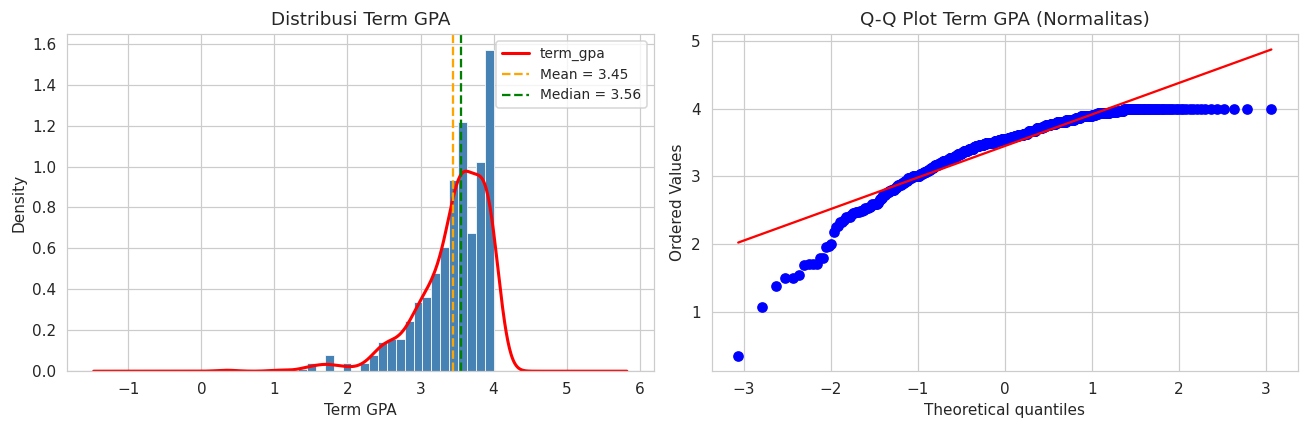

Shapiro-Wilk test: W=0.8536, p=0.0000
Distribusi tidak normal (p < 0.05) — left-skewed, banyak mahasiswa GPA tinggi


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram + KDE
axes[0].hist(df_clean['term_gpa'], bins=30, color='steelblue', edgecolor='white', linewidth=0.5, density=True)
df_clean['term_gpa'].plot.kde(ax=axes[0], color='red', linewidth=2)
axes[0].set_xlabel('Term GPA')
axes[0].set_ylabel('Density')
axes[0].set_title('Distribusi Term GPA')
axes[0].axvline(df_clean['term_gpa'].mean(), color='orange', linestyle='--', linewidth=1.5, label=f"Mean = {df_clean['term_gpa'].mean():.2f}")
axes[0].axvline(df_clean['term_gpa'].median(), color='green', linestyle='--', linewidth=1.5, label=f"Median = {df_clean['term_gpa'].median():.2f}")
axes[0].legend(fontsize=9)

# Q-Q Plot untuk cek normalitas
stats.probplot(df_clean['term_gpa'], dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot Term GPA (Normalitas)')

plt.tight_layout()
plt.show()

# Shapiro-Wilk test
stat, p = stats.shapiro(df_clean['term_gpa'].sample(min(500, len(df_clean)), random_state=42))
print(f"Shapiro-Wilk test: W={stat:.4f}, p={p:.4f}")
print("Distribusi normal" if p > 0.05 else "Distribusi tidak normal (p < 0.05) — left-skewed, banyak mahasiswa GPA tinggi")

## 7. Outlier Detection — IQR Method

IQR (Interquartile Range) = Q3 - Q1  
Batas bawah = Q1 - 1.5 × IQR  
Batas atas  = Q3 + 1.5 × IQR  
Data di luar batas ini diklasifikasikan sebagai outlier.


In [11]:
def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask = (series < lower) | (series > upper)
    return mask, lower, upper, Q1, Q3, IQR

numeric_features = [
    'TotalSleepTime', 'midpoint_sleep', 'bedtime_mssd',
    'daytime_sleep', 'frac_nights_with_data', 'cum_gpa', 'term_gpa'
]

outlier_report = []
for col in numeric_features:
    mask, lower, upper, Q1, Q3, IQR = detect_outliers_iqr(df_clean[col])
    outlier_report.append({
        'Feature': col,
        'Q1': round(Q1, 3),
        'Q3': round(Q3, 3),
        'IQR': round(IQR, 3),
        'Lower Bound': round(lower, 3),
        'Upper Bound': round(upper, 3),
        'N Outliers': mask.sum(),
        'Outlier %': round(mask.sum() / len(df_clean) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_report)
outlier_df

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,N Outliers,Outlier %
0,TotalSleepTime,366.930,430.115,63.185,272.153,524.891,11,1.74
1,midpoint_sleep,345.183,437.655,92.473,206.474,576.364,15,2.37
2,bedtime_mssd,0.075,0.292,0.217,-0.251,0.617,94,14.83
3,daytime_sleep,23.098,51.249,28.151,-19.128,93.475,29,4.57
4,frac_nights_with_data,0.821,1.000,0.179,0.554,1.268,54,8.52
5,cum_gpa,3.232,3.790,0.557,2.396,4.625,17,2.68
6,term_gpa,3.233,3.810,0.577,2.368,4.675,21,3.31


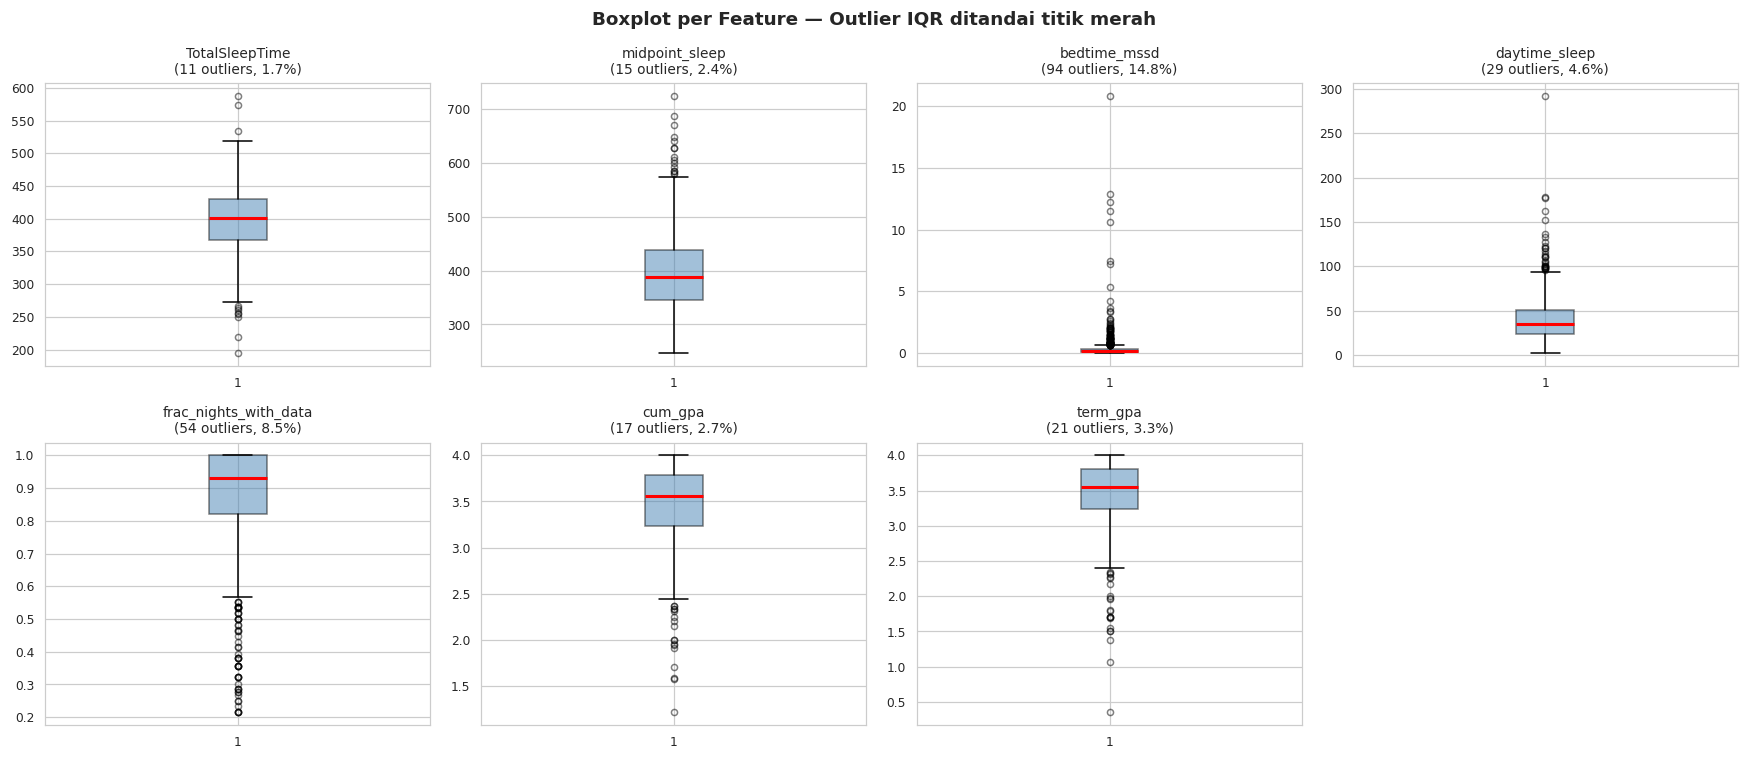

In [12]:
# Boxplot semua fitur numerik
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    mask, lower, upper, _, _, _ = detect_outliers_iqr(df_clean[col])
    
    bp = axes[i].boxplot(df_clean[col], patch_artist=True, vert=True,
                         boxprops=dict(facecolor='steelblue', alpha=0.5),
                         medianprops=dict(color='red', linewidth=2),
                         flierprops=dict(marker='o', markersize=4, alpha=0.5, color='tomato'))
    
    n_out = mask.sum()
    axes[i].set_title(f'{col}\n({n_out} outliers, {n_out/len(df_clean)*100:.1f}%)', fontsize=9)
    axes[i].tick_params(labelsize=8)

axes[-1].set_visible(False)
fig.suptitle('Boxplot per Feature — Outlier IQR ditandai titik merah', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
# Outlier terbanyak: bedtime_mssd — investigasi lebih dalam
mask_mssd, lower_mssd, upper_mssd, _, _, _ = detect_outliers_iqr(df_clean['bedtime_mssd'])

print(f"bedtime_mssd outliers: {mask_mssd.sum()} dari {len(df_clean)} ({mask_mssd.sum()/len(df_clean)*100:.1f}%)")
print(f"Upper bound: {upper_mssd:.3f}")
print()
print("Distribusi outlier bedtime_mssd:")
print(df_clean.loc[mask_mssd, 'bedtime_mssd'].describe().round(3))
print()
print("Rata-rata term_gpa — outlier vs normal:")
print(f"  Outlier:  {df_clean.loc[mask_mssd, 'term_gpa'].mean():.3f}")
print(f"  Normal:   {df_clean.loc[~mask_mssd, 'term_gpa'].mean():.3f}")

bedtime_mssd outliers: 94 dari 634 (14.8%)
Upper bound: 0.617

Distribusi outlier bedtime_mssd:
count    94.000
mean      2.176
std       3.099
min       0.624
25%       0.791
50%       1.190
75%       1.975
max      20.849
Name: bedtime_mssd, dtype: float64

Rata-rata term_gpa — outlier vs normal:
  Outlier:  3.210
  Normal:   3.491


## 8. Outlier Handling

Strategi yang dipilih: **tidak drop outlier, tapi cap (winsorize) di batas IQR.**

Alasan:
- Dataset kecil (n=634), drop outlier mengurangi data training secara signifikan
- Outlier di `bedtime_mssd` (94 baris = 14.8%) mungkin valid — mahasiswa dengan jadwal tidur sangat tidak teratur adalah fenomena nyata
- Model Gradient Boosting secara inheren tahan outlier karena tree-based
- Capping mempertahankan informasi arah (abnormal tinggi/rendah) tanpa membiarkan nilai ekstrem mendominasi


In [14]:
df_model = df_clean.copy()

cap_features = ['TotalSleepTime', 'midpoint_sleep', 'bedtime_mssd', 'daytime_sleep']

for col in cap_features:
    mask, lower, upper, _, _, _ = detect_outliers_iqr(df_model[col])
    n_before = mask.sum()
    df_model[col] = df_model[col].clip(lower=lower, upper=upper)
    print(f"{col}: {n_before} nilai di-cap ke [{lower:.2f}, {upper:.2f}]")

print(f"\nShape final: {df_model.shape}")
print("Tidak ada data yang di-drop — semua 634 baris dipertahankan.")

TotalSleepTime: 11 nilai di-cap ke [272.15, 524.89]
midpoint_sleep: 15 nilai di-cap ke [206.47, 576.36]
bedtime_mssd: 94 nilai di-cap ke [-0.25, 0.62]
daytime_sleep: 29 nilai di-cap ke [-19.13, 93.47]

Shape final: (634, 12)
Tidak ada data yang di-drop — semua 634 baris dipertahankan.


## 9. Feature Distribution — Sebelum vs Sesudah Capping

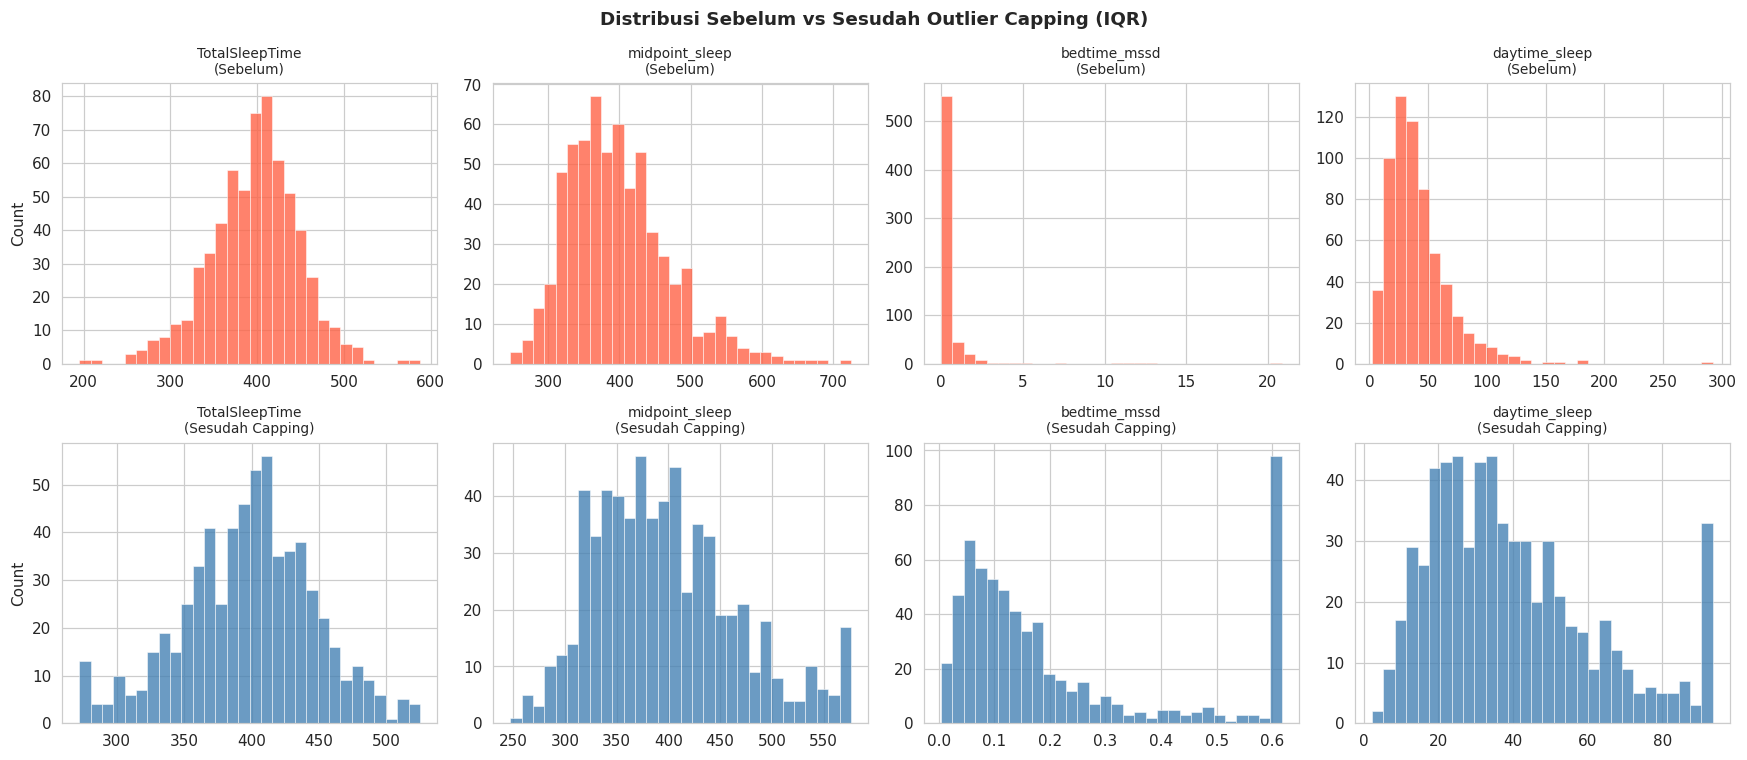

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for i, col in enumerate(cap_features):
    # Sebelum
    axes[0, i].hist(df_clean[col], bins=30, color='tomato', edgecolor='white', linewidth=0.4, alpha=0.8)
    axes[0, i].set_title(f'{col}\n(Sebelum)', fontsize=9)
    axes[0, i].set_ylabel('Count' if i == 0 else '')
    
    # Sesudah
    axes[1, i].hist(df_model[col], bins=30, color='steelblue', edgecolor='white', linewidth=0.4, alpha=0.8)
    axes[1, i].set_title(f'{col}\n(Sesudah Capping)', fontsize=9)
    axes[1, i].set_ylabel('Count' if i == 0 else '')

fig.suptitle('Distribusi Sebelum vs Sesudah Outlier Capping (IQR)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Correlation Analysis

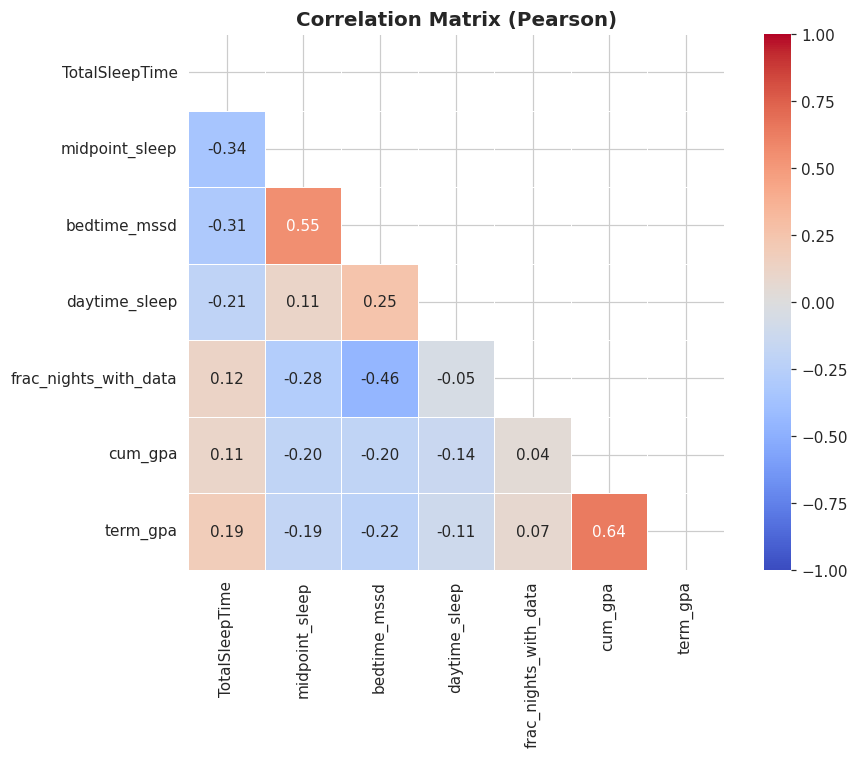

In [16]:
corr_features = [
    'TotalSleepTime', 'midpoint_sleep', 'bedtime_mssd',
    'daytime_sleep', 'frac_nights_with_data', 'cum_gpa', 'term_gpa'
]

corr_matrix = df_model[corr_features].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, annot_kws={'size': 10},
            linewidths=0.5, square=True, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix (Pearson)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

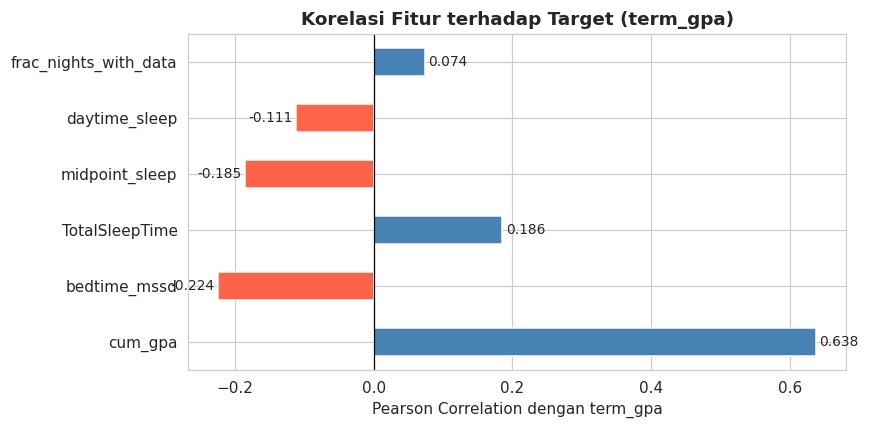


Temuan:
  cum_gpa                       : 0.638 (positif, kuat)
  bedtime_mssd                  : -0.224 (negatif, sedang)
  TotalSleepTime                : 0.186 (positif, sedang)
  midpoint_sleep                : -0.185 (negatif, sedang)
  daytime_sleep                 : -0.111 (negatif, sedang)
  frac_nights_with_data         : 0.074 (positif, lemah)


In [17]:
# Korelasi masing-masing fitur terhadap target (term_gpa)
corr_with_target = df_model[corr_features].corr()['term_gpa'].drop('term_gpa').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['steelblue' if v > 0 else 'tomato' for v in corr_with_target]
corr_with_target.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation dengan term_gpa')
ax.set_title('Korelasi Fitur terhadap Target (term_gpa)', fontweight='bold')
for i, v in enumerate(corr_with_target):
    ax.text(v + (0.005 if v >= 0 else -0.005), i, f'{v:.3f}', 
            va='center', ha='left' if v >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()

print("\nTemuan:")
for feat, val in corr_with_target.items():
    direction = 'positif' if val > 0 else 'negatif'
    strength = 'kuat' if abs(val) > 0.3 else ('sedang' if abs(val) > 0.1 else 'lemah')
    print(f"  {feat:30s}: {val:.3f} ({direction}, {strength})")

## 11. Scatter Plot — Fitur Tidur vs Term GPA

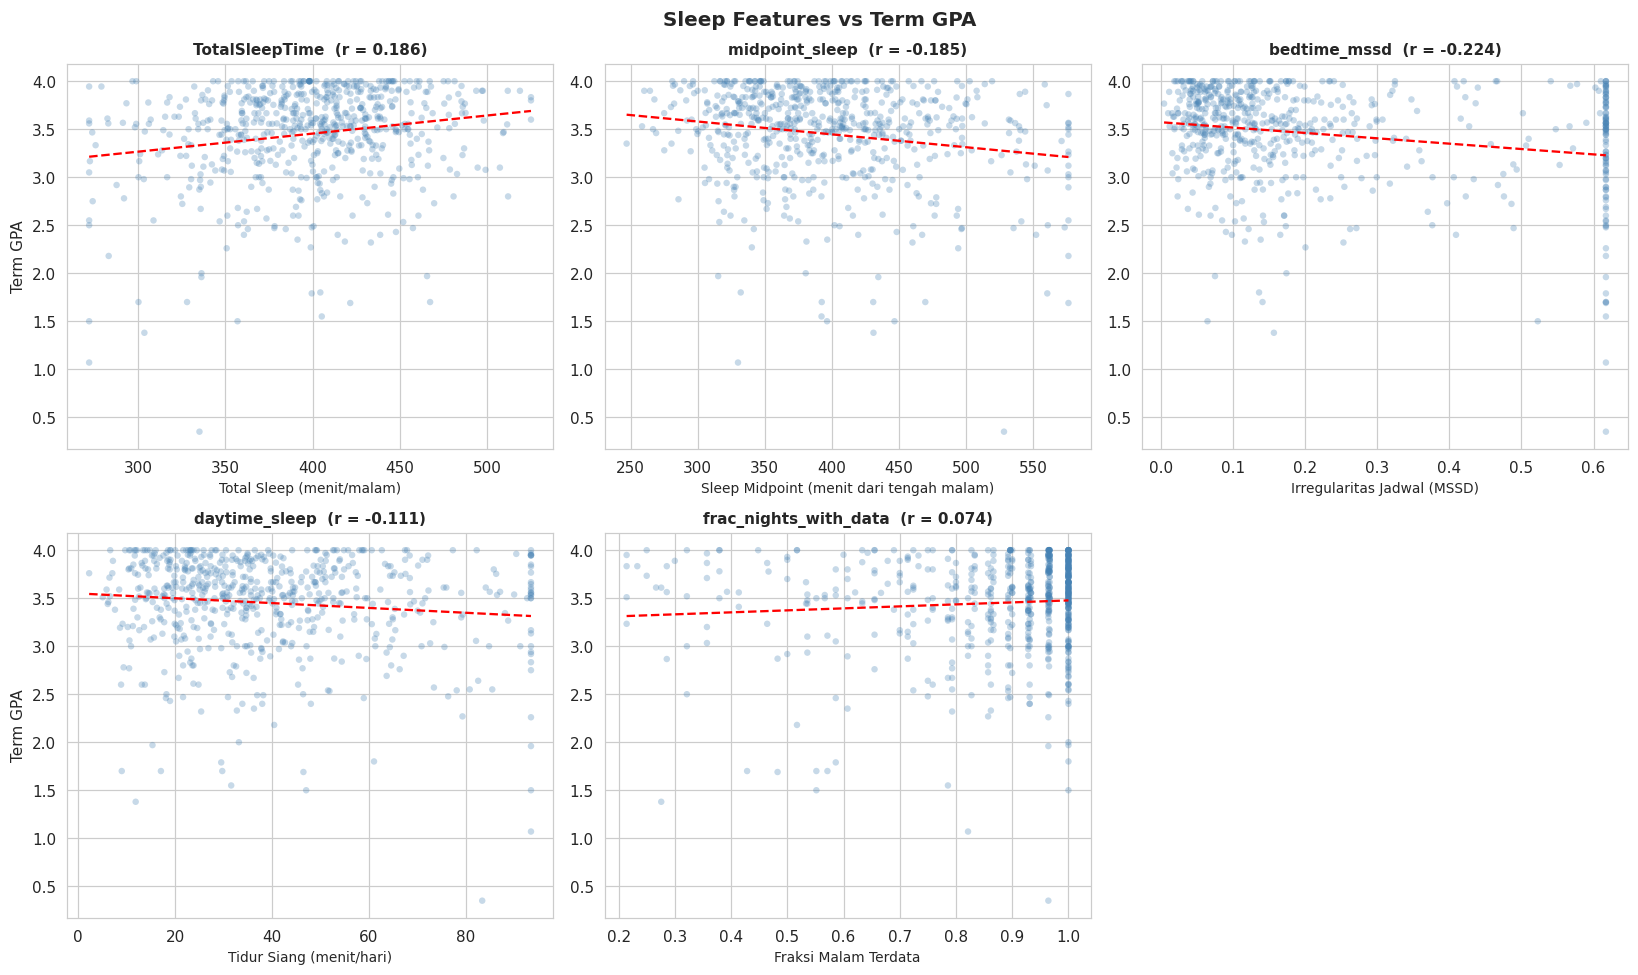

In [18]:
sleep_features = ['TotalSleepTime', 'midpoint_sleep', 'bedtime_mssd', 'daytime_sleep', 'frac_nights_with_data']
labels = [
    'Total Sleep (menit/malam)',
    'Sleep Midpoint (menit dari tengah malam)',
    'Irregularitas Jadwal (MSSD)',
    'Tidur Siang (menit/hari)',
    'Fraksi Malam Terdata'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(sleep_features, labels)):
    axes[i].scatter(df_model[col], df_model['term_gpa'],
                    alpha=0.3, color='steelblue', s=18, edgecolors='none')
    
    # Trendline
    m, b = np.polyfit(df_model[col], df_model['term_gpa'], 1)
    x_line = np.linspace(df_model[col].min(), df_model[col].max(), 100)
    axes[i].plot(x_line, m * x_line + b, 'r--', linewidth=1.5)
    
    r = df_model[[col, 'term_gpa']].corr().iloc[0, 1]
    axes[i].set_xlabel(label, fontsize=9)
    axes[i].set_ylabel('Term GPA' if i % 3 == 0 else '')
    axes[i].set_title(f'{col}  (r = {r:.3f})', fontsize=10, fontweight='bold')

axes[-1].set_visible(False)
fig.suptitle('Sleep Features vs Term GPA', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Cohort Analysis

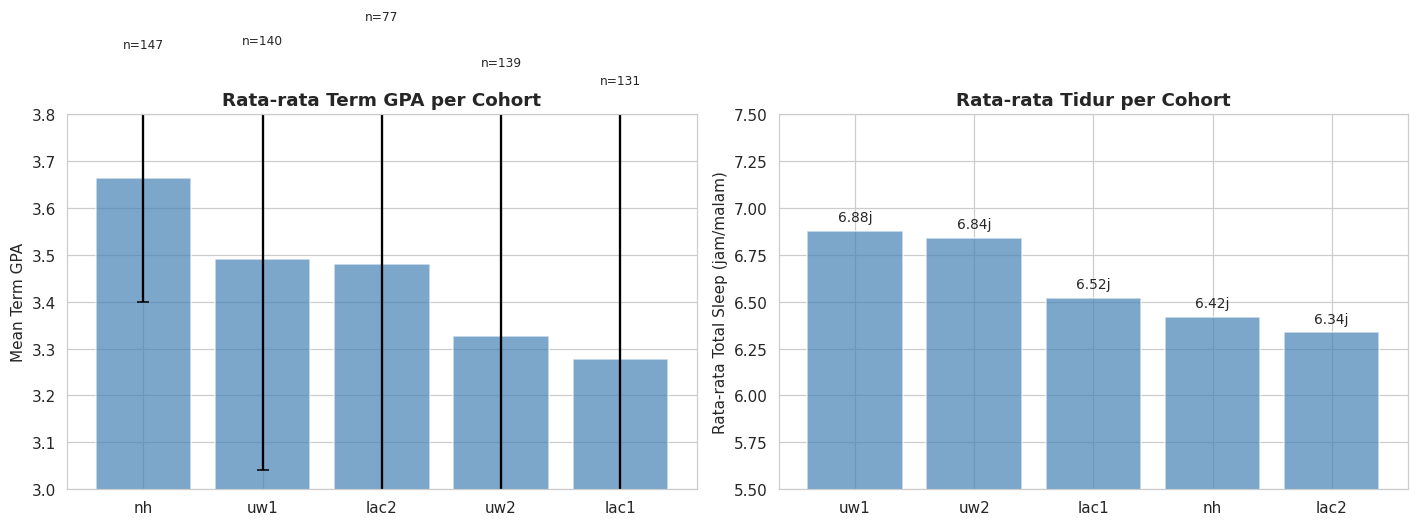

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# GPA per cohort
cohort_gpa = df_model.groupby('cohort')['term_gpa'].agg(['mean', 'std', 'count'])
cohort_gpa = cohort_gpa.sort_values('mean', ascending=False)
axes[0].bar(cohort_gpa.index, cohort_gpa['mean'], 
            yerr=cohort_gpa['std'], capsize=4,
            color='steelblue', alpha=0.7, edgecolor='white')
axes[0].set_ylabel('Mean Term GPA')
axes[0].set_title('Rata-rata Term GPA per Cohort', fontweight='bold')
axes[0].set_ylim(3.0, 3.8)
for i, (idx, row) in enumerate(cohort_gpa.iterrows()):
    axes[0].text(i, row['mean'] + row['std'] + 0.01, f"n={int(row['count'])}", 
                 ha='center', fontsize=8)

# Sleep per cohort
cohort_sleep = df_model.groupby('cohort')['TotalSleepTime'].mean() / 60
cohort_sleep = cohort_sleep.sort_values(ascending=False)
axes[1].bar(cohort_sleep.index, cohort_sleep, color='steelblue', alpha=0.7, edgecolor='white')
axes[1].set_ylabel('Rata-rata Total Sleep (jam/malam)')
axes[1].set_title('Rata-rata Tidur per Cohort', fontweight='bold')
axes[1].set_ylim(5.5, 7.5)
for i, (idx, val) in enumerate(cohort_sleep.items()):
    axes[1].text(i, val + 0.05, f'{val:.2f}j', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 13. Final Dataset Summary

In [20]:
print("=" * 55)
print("RINGKASAN DATASET FINAL UNTUK MODELLING")
print("=" * 55)
print(f"Total rows        : {len(df_model)}")
print(f"Total features    : {len(corr_features) - 1} (tidak termasuk target)")
print(f"Target variable   : term_gpa")
print(f"Missing values    : {df_model.isnull().sum().sum()}")
print()
print("Outlier handling  : Capping IQR (tidak ada data yang di-drop)")
print("Imputation        : Modus untuk demo_gender, demo_firstgen, demo_race")
print("Drop kolom        : subject_id, term_units, Zterm_units_ZofZ")
print()
print("Korelasi tertinggi dengan term_gpa:")
for feat, val in corr_with_target.head(3).items():
    print(f"  {feat}: {val:.3f}")

print()
print("Dataset siap untuk training model.")

RINGKASAN DATASET FINAL UNTUK MODELLING
Total rows        : 634
Total features    : 6 (tidak termasuk target)
Target variable   : term_gpa
Missing values    : 0

Outlier handling  : Capping IQR (tidak ada data yang di-drop)
Imputation        : Modus untuk demo_gender, demo_firstgen, demo_race
Drop kolom        : subject_id, term_units, Zterm_units_ZofZ

Korelasi tertinggi dengan term_gpa:
  cum_gpa: 0.638
  bedtime_mssd: -0.224
  TotalSleepTime: 0.186

Dataset siap untuk training model.


In [21]:
# Export clean dataset untuk dipakai di train.py
df_model.to_csv('data/cmu-sleep-clean.csv', index=False)
print("Dataset clean disimpan ke data/cmu-sleep-clean.csv")

Dataset clean disimpan ke data/cmu-sleep-clean.csv
